# 8차시 강사용 Notebook — 공정 이상과 원인 후보 찾기

**핵심 메시지**: 상관관계는 원인을 증명하지 않는다. '원인 후보'라는 표현을 계속 사용한다.

## 1단계. 데이터 불러오기
**예상 결과**: 450행 12열.

In [1]:
import pandas as pd

df = pd.read_csv("../../data/weekly/week08/week08_anomaly_root_cause.csv")
print(df.shape)
df.head()

(450, 12)


,측정시간,로트번호,설비번호,공정명,온도_섭씨,압력_Pa,진공도_mTorr,두께_nm,진동_mm_s,냉각수온도_섭씨,습도_pct,합격여부
0,2024-03-01 00:00,LOT-0404,EQ-02,식각,303.4,1017.3,4.92,104.66,0.682,19.52,47.4,1
1,2024-03-01 04:00,LOT-0094,EQ-04,증착,302.1,1016.5,5.12,100.03,0.472,20.90,50.4,1
2,2024-03-01 07:00,LOT-0408,EQ-02,증착,295.6,1018.4,5.24,98.62,0.636,19.00,45.7,-1
3,2024-03-01 22:00,LOT-0721,EQ-04,식각,298.4,1010.8,4.55,93.92,0.499,19.26,43.3,1
4,2024-03-02 08:00,LOT-0455,EQ-02,산화,300.1,1015.9,5.27,101.28,0.728,20.43,43.0,1


## 2단계. 진공도 정상 범위 이탈 데이터 찾기
**예상 결과**: 이탈 행 수 약 78건.

In [2]:
vac_low, vac_high = 4.5, 5.5
vac_outlier = df[(df["진공도_mTorr"] < vac_low) | (df["진공도_mTorr"] > vac_high)]
print("진공도 이탈 행 수:", len(vac_outlier))

진공도 이탈 행 수: 78


## 3단계. 진공도 이탈 여부에 따른 불합격률 비교
**예상 결과**: 정상 범위 안 약 8.06%, 밖 약 25.64% — 약 3배 차이.
**어려워할 부분**: `합격여부==-1`이 '불합격'이라는 부호 규칙을 다시 상기시켜야 한다.

In [3]:
df["불합격여부_숫자"] = (df["합격여부"] == -1).astype(int)

is_out = (df["진공도_mTorr"] < vac_low) | (df["진공도_mTorr"] > vac_high)
fail_in = df.loc[~is_out, "불합격여부_숫자"].mean() * 100
fail_out = df.loc[is_out, "불합격여부_숫자"].mean() * 100
print(f"정상 범위 안 불합격률: {fail_in:.2f}%")
print(f"정상 범위 밖 불합격률: {fail_out:.2f}%")

정상 범위 안 불합격률: 8.06%
정상 범위 밖 불합격률: 25.64%


## 4단계. 온도와 두께의 관계
**예상 결과**: r ≈ 0.71 (뚜렷한 양의 상관).

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44760 (\N{HANGUL SYLLABLE GGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49453 (\N{H

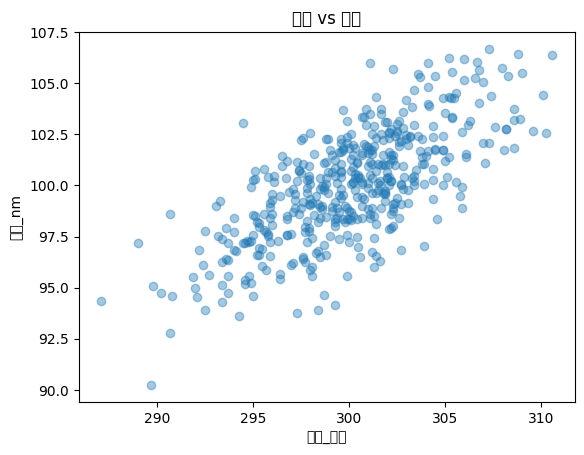

상관계수 r = 0.71


In [4]:
import matplotlib.pyplot as plt

plt.scatter(df["온도_섭씨"], df["두께_nm"], alpha=0.4)
plt.xlabel("온도_섭씨"); plt.ylabel("두께_nm"); plt.title("온도 vs 두께")
plt.show()

r = df["온도_섭씨"].corr(df["두께_nm"])
print("상관계수 r =", round(r, 2))

## 5단계. 습도(대조군) 확인
**예상 결과**: r ≈ -0.13, 온도-두께보다 0에 훨씬 가까움.
**설명 포인트**: 상관계수(0.06)만 봤다면 놓쳤을 패턴이 있을 수도 있다는 것과, 반대로
여기서는 '관계가 없다'는 것 자체가 의도된 설계였다는 점을 함께 짚는다.

In [5]:
r_humid = df["습도_pct"].corr(df["불합격여부_숫자"])
print("습도-불합격 상관계수 r =", round(r_humid, 2))

습도-불합격 상관계수 r = -0.13


## 6단계. EQ-02의 진동 값 확인
**예상 결과**: EQ-02의 평균 진동이 다른 설비보다 뚜렷하게 높음.

In [6]:
df.groupby("설비번호")["진동_mm_s"].mean().round(3)

설비번호
EQ-01    0.507
EQ-02    0.678
EQ-03    0.503
EQ-04    0.501
Name: 진동_mm_s, dtype: float64

## 7단계. 냉각수온도 → 공정온도 시차 패턴(확장)
시간순으로 정렬한 뒤 냉각수온도가 오른 구간 근처에서 온도도 따라 오르는지 시각적으로 확인.

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45257 (\N{HANGUL SYLLABLE NAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\

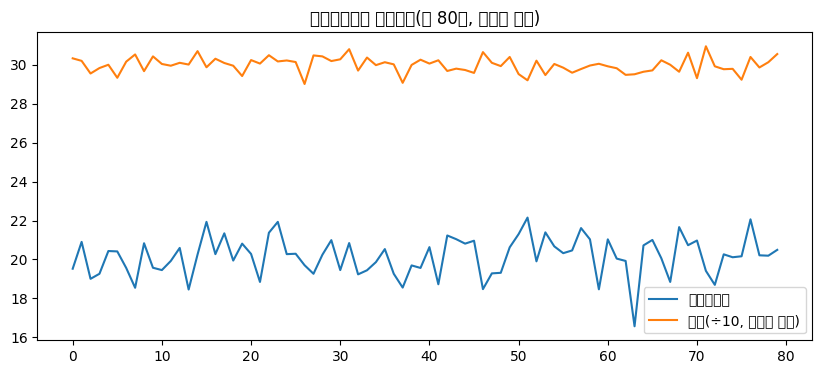

In [7]:
df_sorted = df.sort_values("측정시간").reset_index(drop=True)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df_sorted.index[:80], df_sorted["냉각수온도_섭씨"][:80], label="냉각수온도")
ax1.plot(df_sorted.index[:80], df_sorted["온도_섭씨"][:80] / 10, label="온도(÷10, 스케일 맞춤)")
ax1.legend()
ax1.set_title("냉각수온도와 공정온도(앞 80건, 스케일 조정)")
plt.show()

## 오류 대처 방법
- `&`, `|`를 `and`, `or`로 잘못 쓰면 `ValueError`가 발생한다 — Pandas 조건식 규칙을 다시 안내.
- `corr()`는 숫자 열끼리만 계산된다는 점을 다시 강조.

## 확장 실습(빠른 학습자용)
압력_Pa와 불합격 사이의 관계도 같은 방식(임계값 비교)으로 확인해보게 한다.